In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
from pandas.plotting import parallel_coordinates

sns.set_theme(style="whitegrid")

1. Обрати унікальний датасет з https://archive.ics.uci.edu/datasets , який відповідає наступним вимогам:
Dataset Characteristics: Multivariate
Attribute Characteristics: Categorical, Integer, Real
Number of Attributes: at least 2 integers/real
Has Missing Values: Yes
Можна обрати датасет з інших ресурсів, але з цими ж вимогами.

Тож я обрала класичний датасет Automobile. Створив Jeffrey Schlimmer. 

In [2]:
automobile = fetch_ucirepo(id=10)

X = automobile.data.features
y = automobile.data.targets
df = pd.concat([X, y], axis=1)

print(df.shape)
print(df.dtypes)
df.head()

(205, 26)
price                float64
highway-mpg            int64
city-mpg               int64
peak-rpm             float64
horsepower           float64
compression-ratio    float64
stroke               float64
bore                 float64
fuel-system              str
engine-size            int64
num-of-cylinders       int64
engine-type              str
curb-weight            int64
height               float64
width                float64
length               float64
wheel-base           float64
engine-location          str
drive-wheels             str
body-style               str
num-of-doors         float64
aspiration               str
fuel-type                str
make                     str
normalized-losses    float64
symboling              int64
dtype: object


,price,highway-mpg,city-mpg,peak-rpm,horsepower,compression-ratio,stroke,bore,fuel-system,engine-size,...,wheel-base,engine-location,drive-wheels,body-style,num-of-doors,aspiration,fuel-type,make,normalized-losses,symboling
0,13495.0,27,21,5000.0,111.0,9.0,2.68,3.47,mpfi,130,...,88.6,front,rwd,convertible,2.0,std,gas,alfa-romero,NaN,3
1,16500.0,27,21,5000.0,111.0,9.0,2.68,3.47,mpfi,130,...,88.6,front,rwd,convertible,2.0,std,gas,alfa-romero,NaN,3
2,16500.0,26,19,5000.0,154.0,9.0,3.47,2.68,mpfi,152,...,94.5,front,rwd,hatchback,2.0,std,gas,alfa-romero,NaN,1
3,13950.0,30,24,5500.0,102.0,10.0,3.40,3.19,mpfi,109,...,99.8,front,fwd,sedan,4.0,std,gas,audi,164.0,2
4,17450.0,22,18,5500.0,115.0,8.0,3.40,3.19,mpfi,136,...,99.4,front,4wd,sedan,4.0,std,gas,audi,164.0,2


2. Здійснити Data Cleaning

In [3]:
print("Пропуски до очищення:")
print(df.isnull().sum())

# Числові колонки, де можуть бути пропуски
num_cols = ["normalized-losses", "bore", "stroke",
            "horsepower", "peak-rpm", "price"]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print(f"\nРозмір до очищення: {df.shape}")
df = df.dropna(subset=num_cols)
print(f"Розмір після очищення: {df.shape}")

df.describe()

Пропуски до очищення:
price                 4
highway-mpg           0
city-mpg              0
peak-rpm              2
horsepower            2
compression-ratio     0
stroke                4
bore                  4
fuel-system           0
engine-size           0
num-of-cylinders      0
engine-type           0
curb-weight           0
height                0
width                 0
length                0
wheel-base            0
engine-location       0
drive-wheels          0
body-style            0
num-of-doors          2
aspiration            0
fuel-type             0
make                  0
normalized-losses    41
symboling             0
dtype: int64

Розмір до очищення: (205, 26)
Розмір після очищення: (160, 26)


,price,highway-mpg,city-mpg,peak-rpm,horsepower,compression-ratio,stroke,bore,engine-size,num-of-cylinders,curb-weight,height,width,length,wheel-base,num-of-doors,normalized-losses,symboling
count,160.000000,160.000000,160.000000,160.000000,160.000000,160.000000,160.000000,160.000000,160.000000,160.000000,160.000000,160.000000,160.000000,160.000000,160.000000,159.000000,160.000000,160.000000
mean,11427.681250,32.068750,26.506250,5116.250000,95.875000,10.145125,3.237313,3.298437,119.093750,4.237500,2459.450000,53.878750,65.596250,172.319375,98.235625,3.194969,121.300000,0.737500
std,5863.789011,6.440948,6.081208,465.290536,30.625708,3.882507,0.294210,0.267348,30.411186,0.668119,480.897834,2.276608,1.946999,11.548860,5.163763,0.983908,35.602417,1.189511
min,5118.000000,18.000000,15.000000,4150.000000,48.000000,7.000000,2.070000,2.540000,61.000000,3.000000,1488.000000,49.400000,60.300000,141.100000,86.600000,2.000000,65.000000,-2.000000
25%,7383.500000,28.000000,23.000000,4800.000000,69.000000,8.700000,3.107500,3.050000,97.000000,4.000000,2073.250000,52.000000,64.000000,165.525000,94.500000,2.000000,94.000000,0.000000
50%,9164.000000,32.000000,26.000000,5200.000000,88.000000,9.000000,3.270000,3.270000,110.000000,4.000000,2338.500000,54.100000,65.400000,172.200000,96.900000,4.000000,114.000000,1.000000
75%,14559.250000,37.000000,31.000000,5500.000000,114.000000,9.400000,3.410000,3.550000,134.500000,4.000000,2808.750000,55.500000,66.500000,177.800000,100.600000,4.000000,148.000000,2.000000
max,35056.000000,54.000000,49.000000,6600.000000,200.000000,23.000000,4.170000,3.940000,258.000000,8.000000,4066.000000,59.800000,71.700000,202.600000,115.600000,4.000000,256.000000,3.000000


3. Побудувати графіки залежності одного integer/real атрибута від іншого (lineplot, scatter etc).

Тож графік 1: Залежність ціни від потужності двигуна

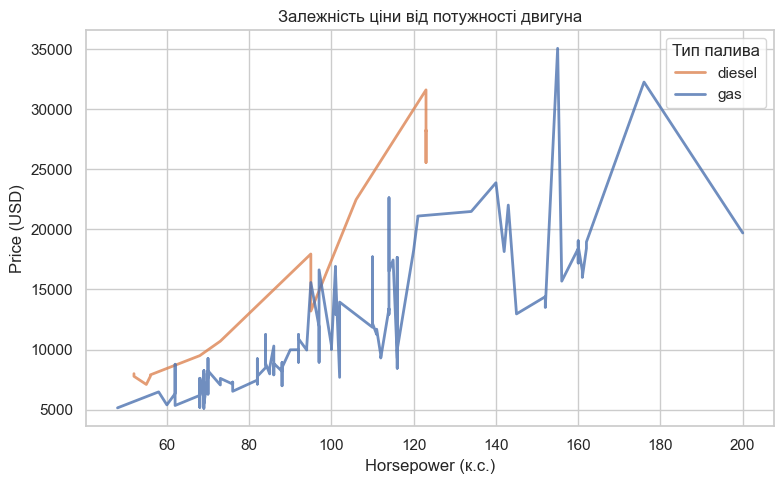

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))

fuel_colors = {"gas": "#4C72B0", "diesel": "#DD8452"}
for fuel, group in df.groupby("fuel-type"):
    group_sorted = group.sort_values(by="horsepower")
    
    ax.plot(group_sorted["horsepower"], group_sorted["price"],
            label=fuel, alpha=0.8, linewidth=2, color=fuel_colors.get(fuel, "gray"))

ax.set_xlabel("Horsepower (к.с.)")
ax.set_ylabel("Price (USD)")
ax.set_title("Залежність ціни від потужності двигуна")
ax.legend(title="Тип палива")
plt.tight_layout()
plt.show()

4. Побудувати гістограму по одному з атрибутів, що буде показувати на кількість елементів, що знаходяться у 5 діапазонах, які ви задасте.

Будую графік 2 як гістограму ціни по 5 діапазонах.

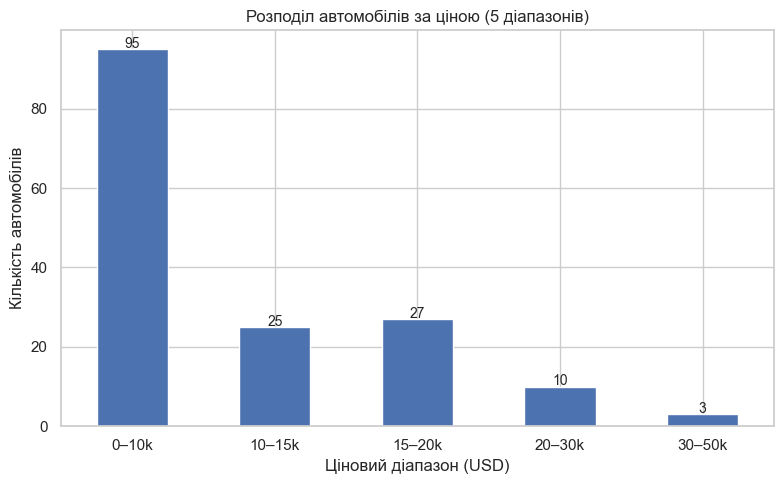

In [5]:
bins  = [0, 10000, 15000, 20000, 30000, 50000]
labels = ["0–10k", "10–15k", "15–20k", "20–30k", "30–50k"]

df["price_bin"] = pd.cut(df["price"], bins=bins, labels=labels)
counts = df["price_bin"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
counts.plot(kind="bar", ax=ax, color="#4C72B0", edgecolor="white")
ax.set_xlabel("Ціновий діапазон (USD)")
ax.set_ylabel("Кількість автомобілів")
ax.set_title("Розподіл автомобілів за ціною (5 діапазонів)")
ax.set_xticklabels(labels, rotation=0)
for i, v in enumerate(counts):
    ax.text(i, v + 0.3, str(v), ha="center", fontsize=10)
plt.tight_layout()
plt.show()

5. Збудувати графіки, використовуючи приклади, наведені у https://medium.com/data-science/the-art-of-effective-visualization-of-multi-dimensional-data-6c7202990c57

Графік 3 у нас pairplot матриця попарних залежностей числових атрибутів, за статтею

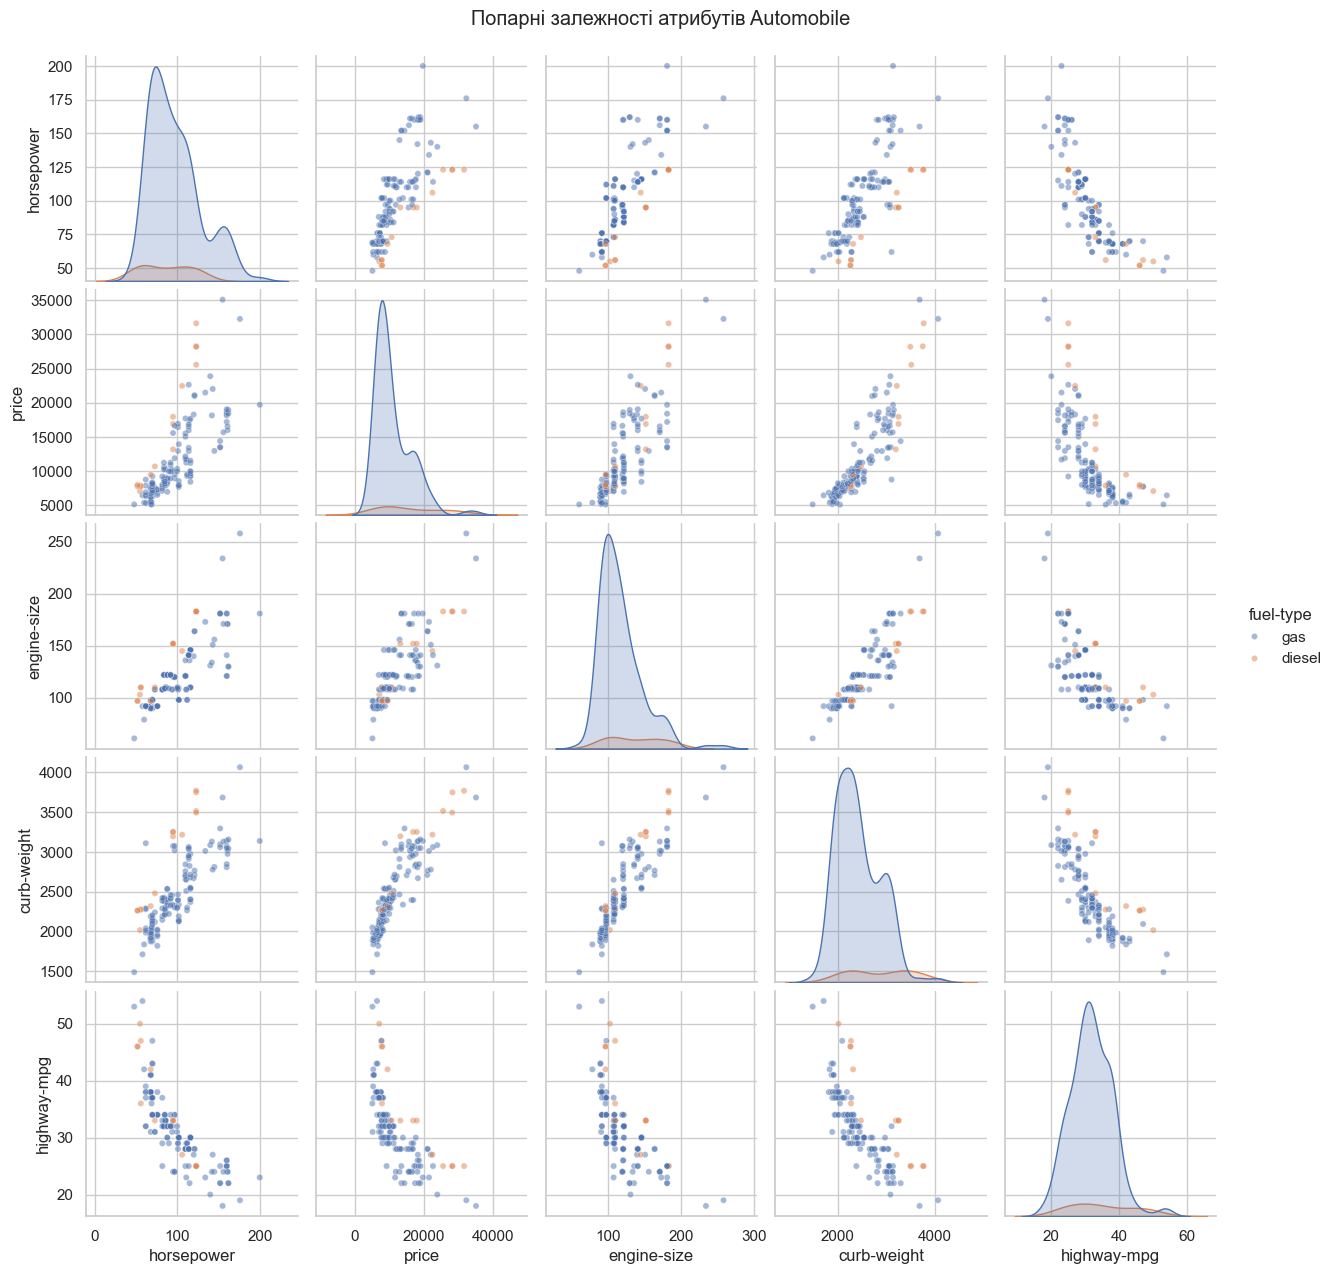

In [6]:
cols = ["horsepower", "price", "engine-size", "curb-weight", "highway-mpg"]

g = sns.pairplot(df[cols + ["fuel-type"]], hue="fuel-type",
                 vars=cols,
                 plot_kws={"alpha": 0.5, "s": 20},
                 palette={"gas": "#4C72B0", "diesel": "#DD8452"})
g.figure.suptitle("Попарні залежності атрибутів Automobile", y=1.02)
plt.show()

6. Побудувати інші графіки, що покажуть корисну інформацію про датасет. Загальна кількість графіків має становити 5-8.

Графік 4. Parallel coordinates. Метод із статті для багатовимірних даних   

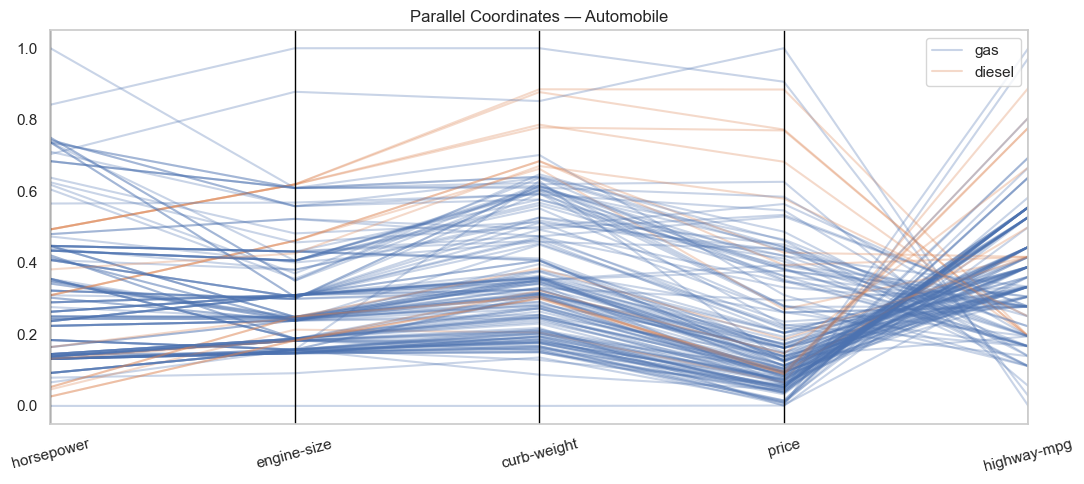

In [7]:
cols_pc = ["horsepower", "engine-size", "curb-weight", "price", "highway-mpg"]
sample = df[cols_pc + ["fuel-type"]].copy()

for c in cols_pc:
    sample[c] = (sample[c] - sample[c].min()) / (sample[c].max() - sample[c].min())

fig, ax = plt.subplots(figsize=(11, 5))
parallel_coordinates(sample, class_column="fuel-type", ax=ax,
                     color=["#4C72B0", "#DD8452"], alpha=0.3)
ax.set_title("Parallel Coordinates — Automobile")
ax.set_xticklabels(cols_pc, rotation=15)
plt.tight_layout()
plt.show()

Графік 5. Розподіл ціни за типом кузова

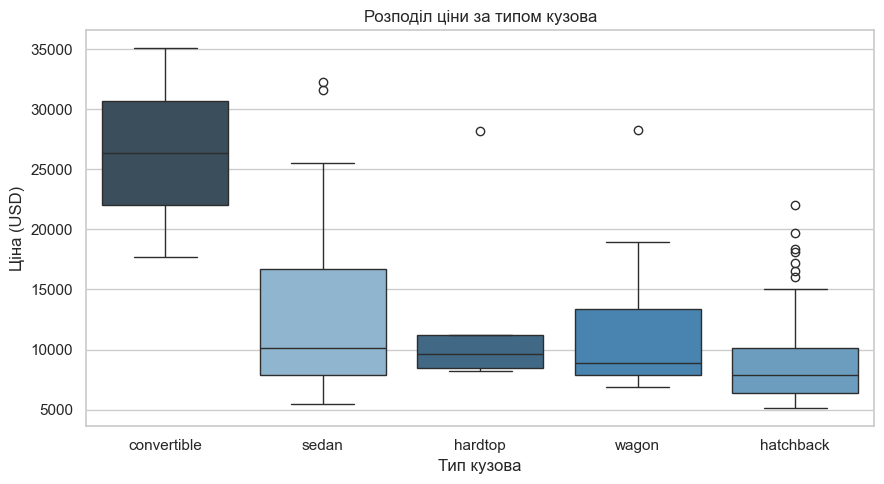

In [8]:
order = df.groupby("body-style")["price"].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(9, 5))

sns.boxplot(data=df, x="body-style", y="price", hue="body-style", order=order,
            palette="Blues_d", legend=False, ax=ax)

ax.set_title("Розподіл ціни за типом кузова")
ax.set_xlabel("Тип кузова")
ax.set_ylabel("Ціна (USD)")
plt.tight_layout()
plt.show()

Графік 6. Кореляційна матриця числових атрибутів

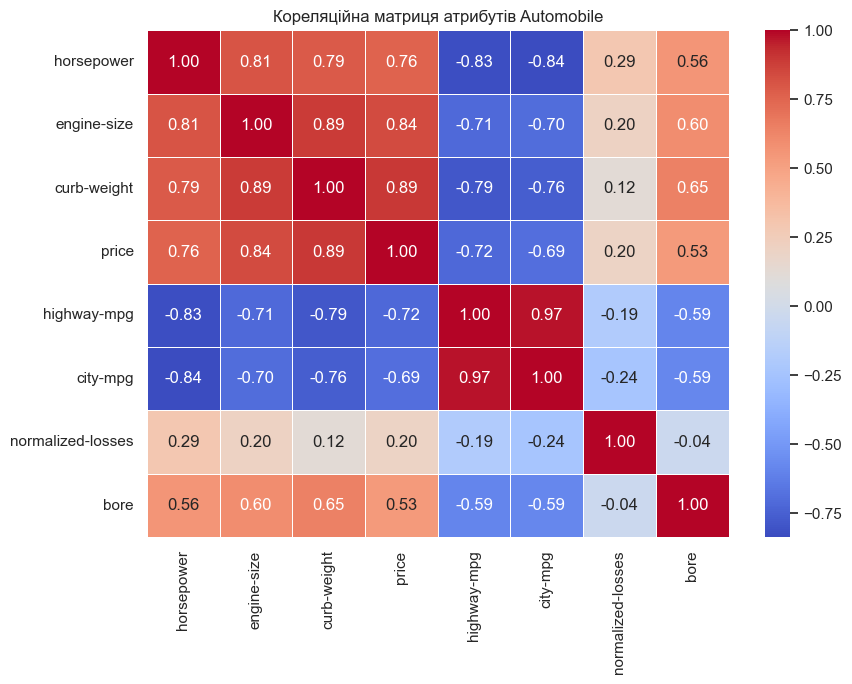

In [9]:
numeric_cols = ["horsepower", "engine-size", "curb-weight",
                "price", "highway-mpg", "city-mpg",
                "normalized-losses", "bore"]

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f",
            cmap="coolwarm", linewidths=0.5, ax=ax)
ax.set_title("Кореляційна матриця атрибутів Automobile")
plt.tight_layout()
plt.show()

Графік 7. Середня ціна за брендом (топ-15)

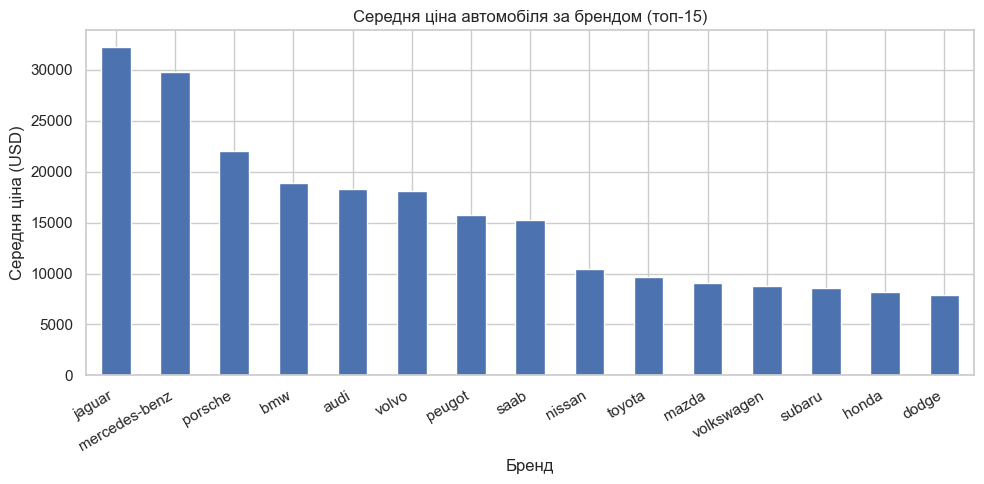

In [10]:
top_makes = (df.groupby("make")["price"]
               .mean()
               .sort_values(ascending=False)
               .head(15))

fig, ax = plt.subplots(figsize=(10, 5))
top_makes.plot(kind="bar", ax=ax, color="#4C72B0", edgecolor="white")
ax.set_title("Середня ціна автомобіля за брендом (топ-15)")
ax.set_xlabel("Бренд")
ax.set_ylabel("Середня ціна (USD)")
ax.set_xticklabels(top_makes.index, rotation=30, ha="right")
plt.tight_layout()
plt.show()